---

# LAB 9: Kalibracja Prawdopodobieństw

---

### Zadanie 1.

---

In [35]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.calibration import calibration_curve

import matplotlib.pyplot as plt
import numpy as np

In [36]:
X,y = make_classification(n_samples=5000, n_features=20, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

X_train_val_cal, X_test, y_train_val_cal, y_test = train_test_split(X, y, test_size=0.2)

In [37]:
class Classifier(nn.Module):
    def __init__(self, input_size: int, hidden: list, num_classes: int):
        super(Classifier, self).__init__()

        self.input = nn.Linear(input_size, hidden[0])
        self.hidden = nn.ModuleList(
            [nn.Linear(hidden[i], hidden[i+1]) for i in range(len(hidden)-1)]
        )
        self.output = nn.Linear(hidden[-1], num_classes)

    def forward(self, x):
        out = self.input(x)
        for layer in self.hidden:
            out = layer(out)
        out = self.output(out)
        return out

In [38]:
def train_models(n_epochs):
    skf = StratifiedKFold(n_splits=5)
    val_losses = {}
    train_losses = {}

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_val_cal, y_train_val_cal)):
        model = Classifier(input_size=20, hidden=[64, 32], num_classes=2)
        loss_fn = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        X_train, y_train = X_train_val_cal[train_idx], y_train_val_cal[train_idx]
        X_val, y_val = X_train_val_cal[val_idx], y_train_val_cal[val_idx]

        val_fold_losses = []
        train_fold_losses = []
        best_val_loss = float('inf')

        for epoch in range(n_epochs):
            model.train()
            optimizer.zero_grad()
            outputs = model(X_train)
            loss = loss_fn(outputs, y_train)
            loss.backward()
            optimizer.step()

            train_fold_losses.append(loss.item())

            with torch.inference_mode():
                model.eval()
                val_outputs = model(X_val)
                val_loss = loss_fn(val_outputs, y_val)
                val_fold_losses.append(val_loss.item())
                
                if val_loss.item() < best_val_loss:
                    best_val_loss = val_loss.item()

                    dic = {
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'epoch': epoch,
                        'train_losses': train_fold_losses,
                        'val_losses': val_fold_losses
                    }

                    torch.save(dic, f'best_model_fold_{fold}.pth')

        val_losses[fold] = val_fold_losses
        train_losses[fold] = train_fold_losses

    return val_losses, train_losses

In [39]:
train_losses, val_losses = train_models(n_epochs=20)

In [40]:
def evaluate_model(model_path, X_test, y_test):
    checkpoint = torch.load(model_path)
    model = Classifier(input_size=20, hidden=[64, 32], num_classes=2)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    with torch.inference_mode():
        outputs = model(X_test)
        _, predicted = torch.max(outputs, 1)

    report = classification_report(y_test, predicted)

    return report

In [41]:
for fold in range(5):
    report = evaluate_model(f'best_model_fold_{fold}.pth', X_test, y_test)
    print(f"Classification Report for Fold {fold}:\n{report}\n")

Classification Report for Fold 0:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       468
           1       0.86      0.87      0.87       532

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000


Classification Report for Fold 1:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       468
           1       0.86      0.87      0.86       532

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000


Classification Report for Fold 2:
              precision    recall  f1-score   support

           0       0.87      0.78      0.82       468
           1       0.82      0.89      0.86       532

    accuracy                           0.84      1000
   macro avg       0.85 

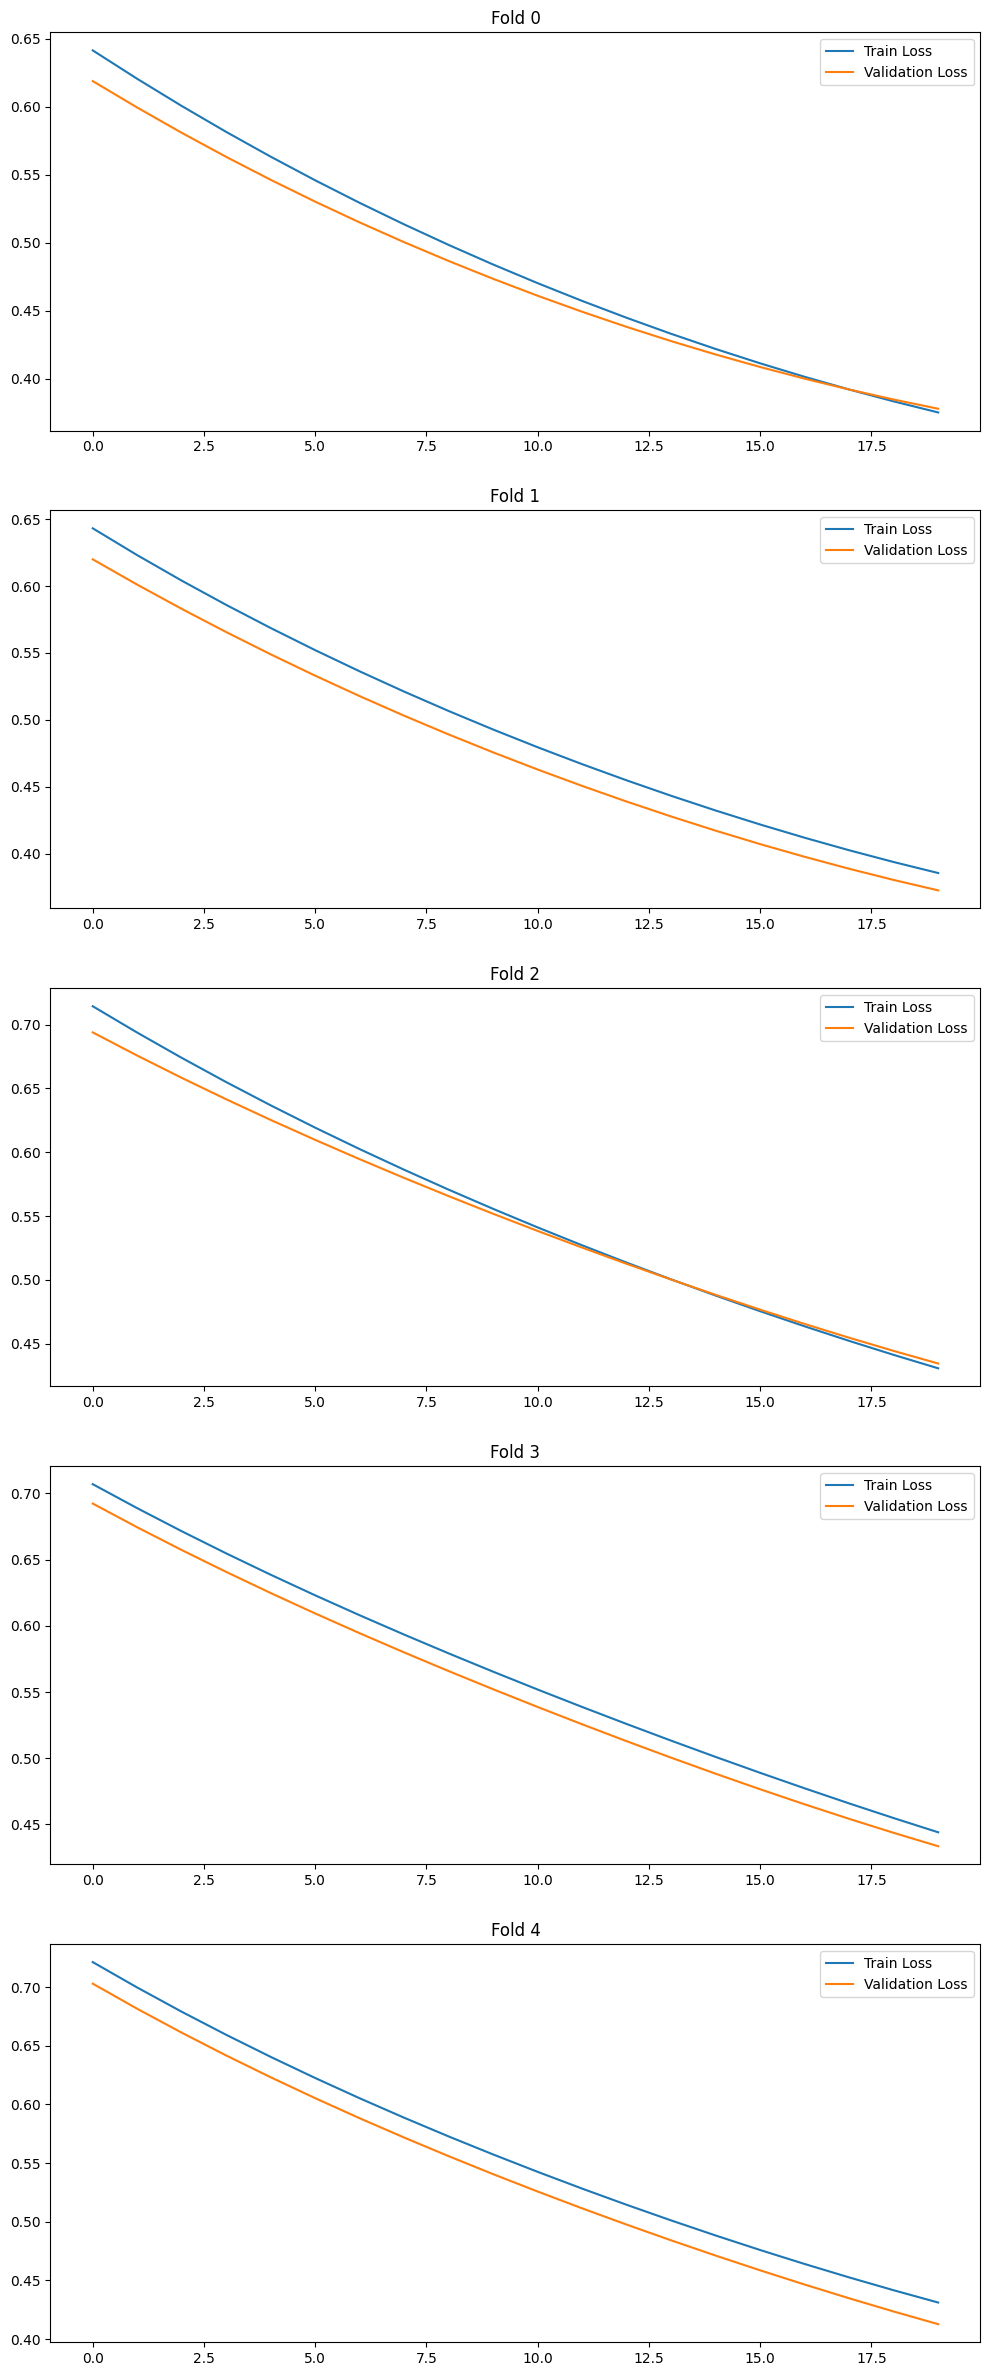

In [42]:
fig = plt.figure(figsize=(12, 30))
axes = fig.subplots(5, 1)

for fold in range(5):
    train_losses, val_losses = torch.load(f'best_model_fold_{fold}.pth')['train_losses'], torch.load(f'best_model_fold_{fold}.pth')['val_losses']
    axes[fold].plot(train_losses, label='Train Loss')
    axes[fold].plot(val_losses, label='Validation Loss')
    axes[fold].set_title(f'Fold {fold}')
    axes[fold].legend()

plt.show()

In [43]:
class TemperatureScaler(nn.Module):
    def __init__(self,model):
        super(TemperatureScaler, self).__init__()
        self.model = model
        model.eval()
        self.temperature = nn.Parameter(torch.ones(1))
    
    def forward(self,x):
        with torch.no_grad():
            logits = self.model(x)
        
        return logits / self.temperature
    
def fit_temperature(model, X_val, y_val):
    scaler = TemperatureScaler(model)
    optimizer = optim.LBFGS([scaler.temperature], lr=0.001, max_iter=15000)
    loss_fn = nn.CrossEntropyLoss()

    def closure():
        optimizer.zero_grad()
        outputs = scaler(X_val)
        loss = loss_fn(outputs, y_val)
        loss.backward()
        return loss
    optimizer.step(closure)
    return scaler

Optimal temperature for fold 0: 0.5540996789932251


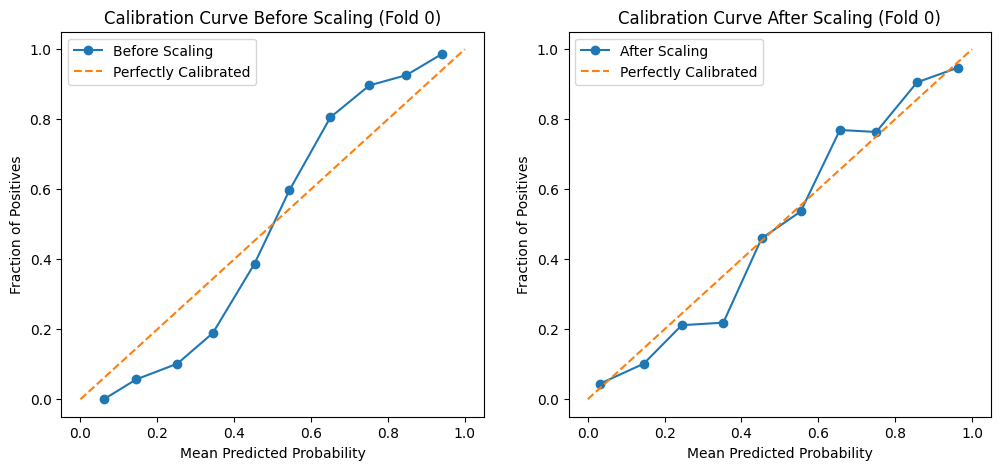

Optimal temperature for fold 1: 0.5139147043228149


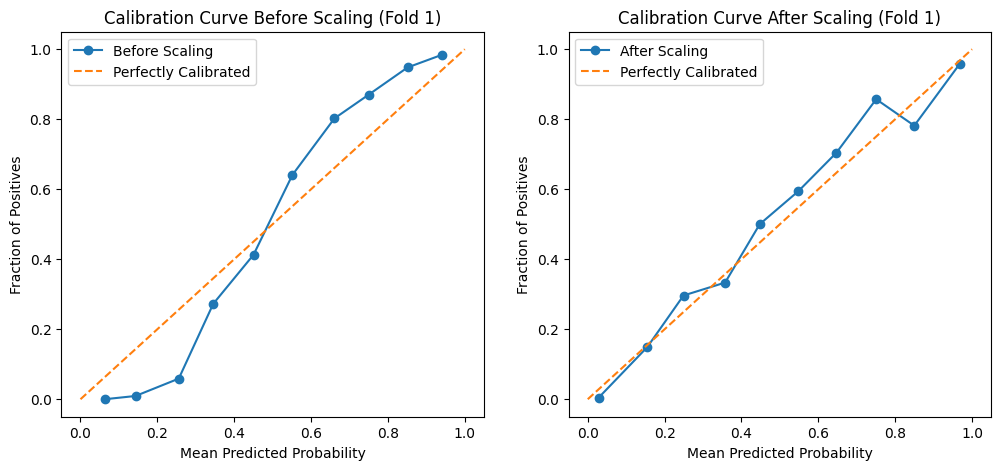

Optimal temperature for fold 2: 0.37409284710884094


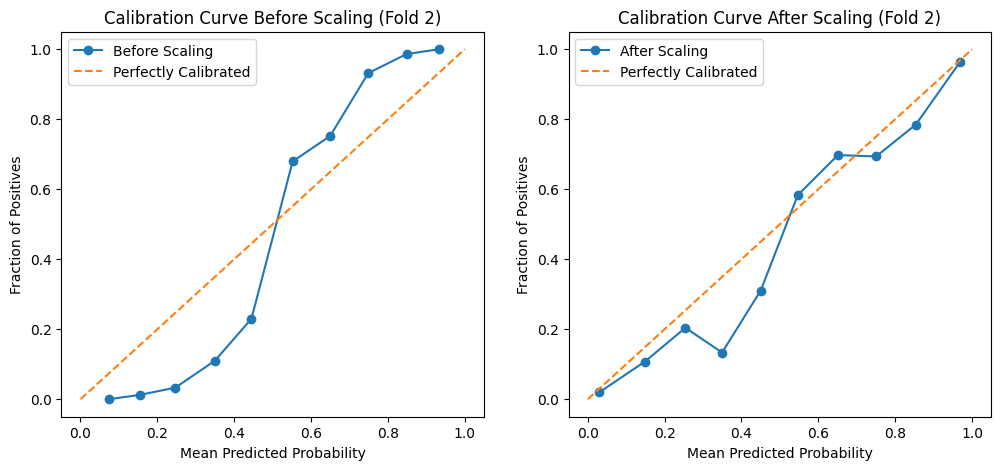

Optimal temperature for fold 3: 0.35036149621009827


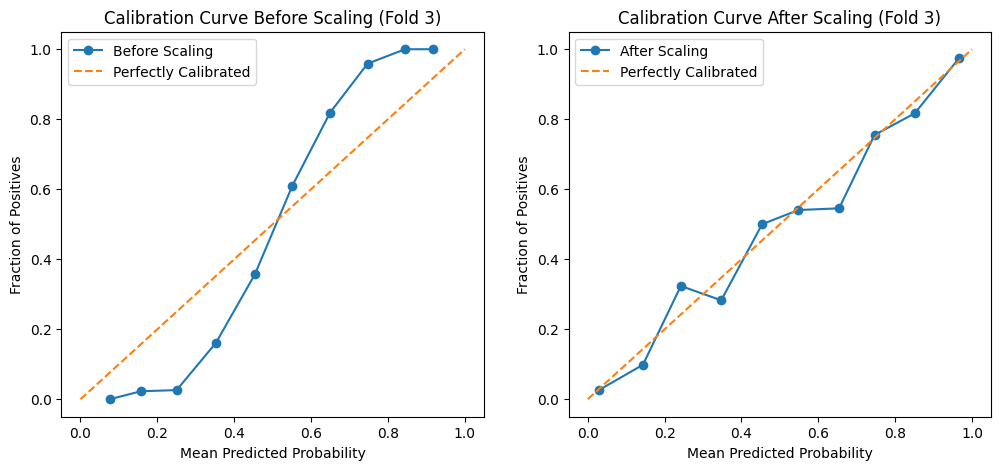

Optimal temperature for fold 4: 0.38104763627052307


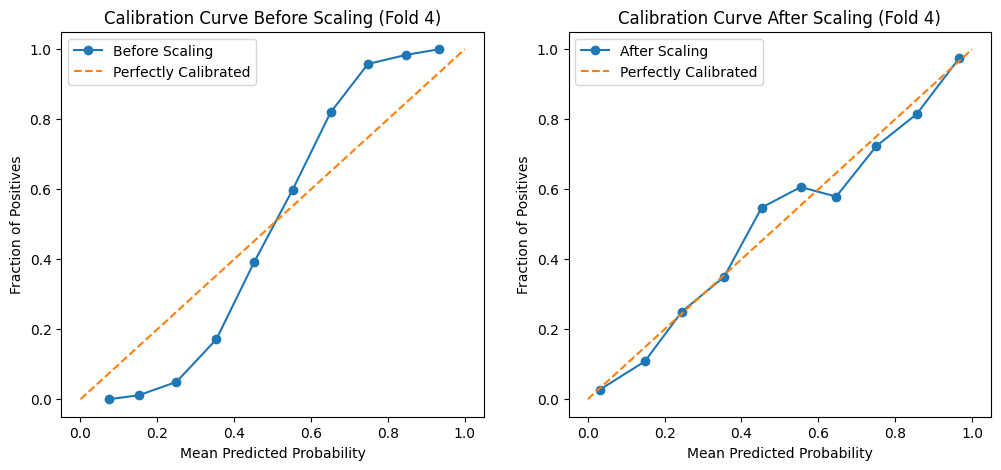

In [44]:
for fold in range(5):
    checkpoint = torch.load(f'best_model_fold_{fold}.pth')
    model = Classifier(input_size=20, hidden=[64, 32], num_classes=2)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    _, X_val, _, y_val = train_test_split(X_train_val_cal, y_train_val_cal, test_size=0.2)

    scaler = fit_temperature(model, X_val, y_val)

    print(f"Optimal temperature for fold {fold}: {scaler.temperature.item()}")

    logits = model(X_val).detach()
    probs_before = torch.softmax(logits, dim=1)[:, 1].numpy()

    logits_scaled = scaler(X_val).detach()
    probs_after = torch.softmax(logits_scaled, dim=1)[:, 1].numpy()

    frac_pos_before = calibration_curve(y_val.numpy(), probs_before, n_bins=10)
    frac_pos_after = calibration_curve(y_val.numpy(), probs_after, n_bins=10)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(frac_pos_before[1], frac_pos_before[0], marker='o', label='Before Scaling')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
    plt.title(f'Calibration Curve Before Scaling (Fold {fold})')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(frac_pos_after[1], frac_pos_after[0], marker='o', label='After Scaling')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
    plt.title(f'Calibration Curve After Scaling (Fold {fold})')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.legend()
    plt.show()




RuntimeError: Inference tensors cannot be saved for backward. Please do not use Tensors created in inference mode in computation tracked by autograd. To work around this, you can make a clone to get a normal tensor and use it in autograd, or use `torch.no_grad()` instead of `torch.inference_mode()`.


---

### Zadanie 3. Wrapper scikit-learn

---

In [45]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted

In [46]:
class MyWrapper(ClassifierMixin, BaseEstimator):
    def __init__(
        self,
        model,
        classes,
        lr=1e-3,
        epochs=50,
        batch_size=None,
        device=None,
        is_fitted=False
                 
    ):
        self.model = model
        self.classes = classes
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.device = device
        self.is_fitted = is_fitted

    def fit(self, X, y):
        self.model.to(self.device)
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        loss_fn = nn.CrossEntropyLoss()

        dataset = torch.utils.data.TensorDataset(X, y)
        dataloader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        for epoch in range(self.epochs):
            self.model.train()
            for batch_X, batch_y in dataloader:
                batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = loss_fn(outputs, batch_y)
                loss.backward()
                optimizer.step()

        self.is_fitted = True
        return self
    
    def predict(self, X):
        check_is_fitted(self, 'is_fitted')
        self.model.to(self.device)
        self.model.eval()

        with torch.inference_mode():
            outputs = self.model(X.to(self.device))
            _, predicted = torch.max(outputs, 1)

        return predicted.cpu().numpy()
    
    def predict_proba(self,X):
        check_is_fitted(self, 'is_fitted')
        self.model.to(self.device)
        self.model.eval()

        with torch.inference_mode():
            outputs = self.model(X.to(self.device))
            probs = torch.softmax(outputs, dim=1)

        return probs.cpu().numpy()
    
    def score(self, X, y):
        check_is_fitted(self, 'is_fitted')
        y_pred = self.predict(X)
        return np.mean(y_pred == y.cpu().numpy())

In [47]:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import cross_val_score

In [48]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

In [49]:
for fold in range(5):
    checkpoint = torch.load(f'best_model_fold_{fold}.pth')
    model = Classifier(input_size=20, hidden=[64, 32], num_classes=2)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    X_train, X_val, y_train, y_val = train_test_split(X_train_val_cal, y_train_val_cal, test_size=0.2)

    clf = MyWrapper(model=model, classes=np.unique(y_train), is_fitted=True)

    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_val)
    scores = cross_val_score(clf, X_val, y_val.cpu().numpy(), cv=5)

    print(confusion_matrix(y_val.cpu().numpy(), y_pred))
    print(accuracy_score(y_val.cpu().numpy(), y_pred))
    print(scores)

    calibrated_clf = CalibratedClassifierCV(FrozenEstimator(clf), method='temperature')

    init_probs = clf.predict_proba(X_val)

    calibrated_probs = calibrated_clf.predict_proba(X_val)

    frac_pos_before,mean_pred_before = calibration_curve(y_val.cpu().numpy(), init_probs[:, 1], n_bins=10)
    frac_pos_after, mean_pred_after = calibration_curve(y_val.cpu().numpy(), calibrated_probs[:, 1], n_bins=10)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(mean_pred_before, frac_pos_before, marker='o', label='Before Calibration')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
    plt.title('Calibration Curve Before Calibration')   
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(mean_pred_after, frac_pos_after, marker='o', label='After Calibration')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
    plt.title('Calibration Curve After Calibration')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.legend()
    plt.show()

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\posze\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\posze\AppData\Local\Temp\ipykernel_18764\3141246979.py", line 26, in fit
    dataset = torch.utils.data.TensorDataset(X, y)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\posze\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataset.py", line 201, in __init__
    assert all(tensors[0].size(0) == tensor.size(0) for tensor in tensors), (
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

---